# Multimodal Movie Recommender

This notebook trains and compares three rating predictors:

- **User-Based CF**: a traditional collaborative filtering baseline using similar users' rating deviations.
- **Baseline NCF**: learns only from user/movie rating history.
- **Multimodal NCF**: starts from the baseline and adds movie metadata plus poster features as a residual correction.

Read the notebook as a pipeline: load processed data, build feature matrices, split ratings, evaluate traditional CF, train the neural baseline, train the multimodal model, compare behavior, generate recommendations, and save the neural models.


## Imports

This section checks/imports the packages and sets project constants. The most important switches are `USE_SAMPLE`, `USE_POSTER_SVD`, and the epoch counts.


In [35]:
import importlib.util
import subprocess
import sys

required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'scipy': 'scipy',
    'sklearn': 'scikit-learn',
    'tensorflow': 'tensorflow',
}

missing = [pkg for module, pkg in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    print('Installing:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('All required packages are already installed.')


All required packages are already installed.


In [36]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import TruncatedSVD

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

USE_SAMPLE = True
USE_POSTER_SVD = True
POSTER_SVD_DIM = 64
POSTER_FALLBACK_DIM = 1


def has_training_data(candidate):
    candidate = Path(candidate)
    has_mappings = (candidate / 'movie2idx.csv').exists() and (candidate / 'user2idx.csv').exists()
    has_sample = (candidate / 'model_sample_500k.csv').exists()
    has_full_model = (candidate / 'model_df_clean.csv').exists()
    has_split_full = (candidate / 'final_ratings_clean.csv').exists() and (candidate / 'final_movie_features_clean.csv').exists()
    return has_mappings and (has_sample or has_full_model or has_split_full)


def resolve_data_dir():
    env_dir = os.environ.get('MOVIE_REC_DATA_DIR')
    if env_dir:
        env_path = Path(env_dir).expanduser().resolve()
        if not has_training_data(env_path):
            raise FileNotFoundError(f'MOVIE_REC_DATA_DIR does not contain the processed dataset files: {env_path}')
        return env_path

    candidates = [
        Path.cwd() / 'MultimodalMovieDataset_v2',
        Path.cwd() / 'dataset' / 'MultimodalMovieDataset_v2',
        Path.cwd(),
        Path.cwd() / 'MultimodalMovieDataset',
        Path.cwd() / 'dataset' / 'MultimodalMovieDataset',
    ]
    for candidate in candidates:
        if has_training_data(candidate):
            return candidate.resolve()
    checked = '\n'.join(str(c.resolve()) for c in candidates)
    raise FileNotFoundError('Could not find processed movie recommender data. Checked:\n' + checked)


def resolve_project_root(data_dir):
    data_dir = Path(data_dir).resolve()
    cwd = Path.cwd().resolve()
    if (cwd / 'movie_recommender.ipynb').exists():
        return cwd
    if data_dir.name in {'MultimodalMovieDataset_v2', 'MultimodalMovieDataset'} and data_dir.parent.name == 'dataset':
        return data_dir.parent.parent.resolve()
    return cwd


DATA_DIR = resolve_data_dir()
PROJECT_ROOT = resolve_project_root(DATA_DIR)

EMBEDDING_DIM   = 32
BATCH_SIZE      = 1024
EPOCHS_BASELINE = 20
EPOCHS_MULTI    = 20
SEED            = 42

RATING_MIN = 0.5
RATING_MAX = 5.0

tf.random.set_seed(SEED)
np.random.seed(SEED)

print('Project root:', PROJECT_ROOT)
print('Data folder :', DATA_DIR)


TensorFlow version: 2.21.0
GPU available: []
Project root: C:\Users\murad\Desktop\master\Neural networks\GroupProject\final
Data folder : C:\Users\murad\Desktop\master\Neural networks\GroupProject\final\dataset\MultimodalMovieDataset_v2


## Load Data

This section loads the processed files created by `dataset/merge.ipynb`:

- rating rows for training/testing,
- user/movie index mappings,
- movie metadata catalog,
- poster embeddings if they already exist.

If `poster_embeddings.npy` is missing, the notebook uses zero poster features so the rest of the pipeline can still be checked. For the real poster experiment, run `extract_poster_embeddings.py` first.


In [37]:
def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Missing required file: {path}')
    return path


TRAINING_USECOLS = [
    'userId', 'movieId', 'rating', 'timestamp', 'user_idx', 'movie_idx',
    'final_title', 'final_genres_str', 'poster_url', 'poster_url_source',
    'poster_imdb_score', 'meta_vote_average', 'meta_vote_count',
    'meta_popularity', 'meta_runtime', 'release_year', 'meta_original_language'
]

MOVIE_CATALOG_USECOLS = [
    'movieId', 'movie_idx', 'final_title', 'final_genres_str', 'poster_url',
    'poster_url_source', 'poster_imdb_score', 'meta_vote_average',
    'meta_vote_count', 'meta_popularity', 'meta_runtime', 'release_year',
    'meta_original_language'
]


def read_training_csv(path):
    return pd.read_csv(path, usecols=lambda c: c in TRAINING_USECOLS)


def load_movie_catalog(data_dir):
    movies_path = data_dir / 'final_movie_features_clean.csv'
    if movies_path.exists():
        return pd.read_csv(movies_path, usecols=lambda c: c in MOVIE_CATALOG_USECOLS)
    return None


def load_training_frame(data_dir, use_sample=True):
    if use_sample:
        sample_path = data_dir / 'model_sample_500k.csv'
        if sample_path.exists():
            print(f'Loading sample file: {sample_path.name}')
            return read_training_csv(sample_path), sample_path.name
        print('model_sample_500k.csv not found; falling back to full data loading.')

    model_path = data_dir / 'model_df_clean.csv'
    if model_path.exists():
        print(f'Loading denormalized full file: {model_path.name}')
        return read_training_csv(model_path), model_path.name

    ratings_path = require_file(data_dir / 'final_ratings_clean.csv')
    movies_path = require_file(data_dir / 'final_movie_features_clean.csv')
    print('model_df_clean.csv not found; merging final_ratings_clean.csv + final_movie_features_clean.csv')
    ratings = pd.read_csv(ratings_path)
    movie_features = pd.read_csv(movies_path, usecols=lambda c: c in MOVIE_CATALOG_USECOLS)
    df_full = ratings.merge(movie_features, on=['movieId', 'movie_idx'], how='left')
    return df_full, 'final_ratings_clean.csv + final_movie_features_clean.csv'


def load_poster_matrix(data_dir, n_movies):
    poster_path = data_dir / 'poster_embeddings.npy'
    if not poster_path.exists():
        print('Warning: poster_embeddings.npy is missing. Using zero poster features so the notebook can still run.')
        print('Run extract_poster_embeddings.py later to enable the visual poster branch.')
        poster_raw = np.zeros((n_movies, POSTER_FALLBACK_DIM), dtype=np.float32)
        return poster_raw, False

    poster_raw = np.load(poster_path).astype(np.float32, copy=False)
    if poster_raw.ndim != 2:
        raise ValueError(f'poster_embeddings.npy must be 2-D, got shape {poster_raw.shape}')

    if poster_raw.shape[0] < n_movies:
        pad = np.zeros((n_movies - poster_raw.shape[0], poster_raw.shape[1]), dtype=np.float32)
        poster_raw = np.vstack([poster_raw, pad])
        print(f'Padded poster embeddings to {poster_raw.shape} to match movie2idx.csv')
    elif poster_raw.shape[0] > n_movies:
        poster_raw = poster_raw[:n_movies]
        print(f'Trimmed poster embeddings to {poster_raw.shape} to match movie2idx.csv')
    return poster_raw, True


df, loaded_from = load_training_frame(DATA_DIR, USE_SAMPLE)
movie_catalog = load_movie_catalog(DATA_DIR)
if movie_catalog is None:
    movie_catalog = df[MOVIE_CATALOG_USECOLS].drop_duplicates('movie_idx').copy()

user2idx_df  = pd.read_csv(require_file(DATA_DIR / 'user2idx.csv'))
movie2idx_df = pd.read_csv(require_file(DATA_DIR / 'movie2idx.csv'))

N_USERS  = int(user2idx_df['user_idx'].max()) + 1
N_MOVIES = int(movie2idx_df['movie_idx'].max()) + 1

if df['user_idx'].max() >= N_USERS:
    raise ValueError('df contains user_idx values outside user2idx.csv')
if df['movie_idx'].max() >= N_MOVIES:
    raise ValueError('df contains movie_idx values outside movie2idx.csv')

poster_raw, poster_file_found = load_poster_matrix(DATA_DIR, N_MOVIES)
poster_available = np.any(poster_raw != 0, axis=1)
unique_df_movies = np.sort(df['movie_idx'].unique())
covered_in_df = int(poster_available[unique_df_movies].sum())

poster_model = np.zeros_like(poster_raw, dtype=np.float32)
if poster_available.any():
    poster_mean = poster_raw[poster_available].mean(axis=0, keepdims=True)
    poster_std = poster_raw[poster_available].std(axis=0, keepdims=True) + 1e-6
    poster_model[poster_available] = (poster_raw[poster_available] - poster_mean) / poster_std

if USE_POSTER_SVD and poster_model.shape[1] > POSTER_SVD_DIM and poster_available.sum() > POSTER_SVD_DIM:
    svd = TruncatedSVD(n_components=POSTER_SVD_DIM, random_state=SEED)
    reduced = np.zeros((N_MOVIES, POSTER_SVD_DIM), dtype=np.float32)
    reduced_present = svd.fit_transform(poster_model[poster_available]).astype(np.float32)
    red_mean = reduced_present.mean(axis=0, keepdims=True)
    red_std = reduced_present.std(axis=0, keepdims=True) + 1e-6
    reduced[poster_available] = (reduced_present - red_mean) / red_std
    poster_model = reduced
    print(f'Poster SVD dim: {POSTER_SVD_DIM}, explained variance: {svd.explained_variance_ratio_.sum():.3f}')

poster_embeddings = np.concatenate(
    [poster_model.astype(np.float32), poster_available.astype(np.float32)[:, None]],
    axis=1
)
POSTER_DIM = poster_embeddings.shape[1]

del poster_raw

print(f'Rows loaded       : {len(df):,} from {loaded_from}')
print(f'Total users       : {N_USERS:,}')
print(f'Total movies      : {N_MOVIES:,}')
print(f'Movie catalog     : {len(movie_catalog):,} rows')
print(f'Poster file found : {poster_file_found}')
print(f'Poster dim        : {POSTER_DIM} ({POSTER_DIM - 1} visual + availability flag)')
print(f'Poster coverage   : {poster_available.sum():,} / {N_MOVIES:,} movies')
print(f'Coverage in df     : {covered_in_df:,} / {len(unique_df_movies):,} unique movies')
if 'poster_url' in df.columns:
    rows_with_poster_url = int(df['poster_url'].notna().sum())
    unique_with_poster_url = int(df.drop_duplicates('movie_idx')['poster_url'].notna().sum())
    print(f'Rows with poster URL in df: {rows_with_poster_url:,} / {len(df):,}')
    print(f'Unique movies with poster URL in df: {unique_with_poster_url:,} / {len(unique_df_movies):,}')
    if poster_file_found and unique_with_poster_url - covered_in_df > 500:
        print('Warning: many movies have poster URLs but no embedding yet. Re-run extract_poster_embeddings.py for this DATA_DIR.')
print(f'Rating range      : {df.rating.min()} - {df.rating.max()}')
df.head(3)


Loading sample file: model_sample_500k.csv
Poster SVD dim: 64, explained variance: 0.464
Rows loaded       : 500,000 from model_sample_500k.csv
Total users       : 162,541
Total movies      : 62,423
Movie catalog     : 62,423 rows
Poster file found : True
Poster dim        : 65 (64 visual + availability flag)
Poster coverage   : 61,139 / 62,423 movies
Coverage in df     : 18,101 / 18,239 unique movies
Rows with poster URL in df: 499,922 / 500,000
Unique movies with poster URL in df: 18,208 / 18,239
Rating range      : 0.5 - 5.0


,userId,movieId,rating,timestamp,user_idx,movie_idx,final_title,final_genres_str,poster_url,poster_url_source,poster_imdb_score,meta_vote_average,meta_vote_count,meta_popularity,meta_runtime,release_year,meta_original_language
0,125655,4330,4.0,1171158819,125654,4225,The Scarlet Empress,Drama|History|Romance,https://image.tmdb.org/t/p/w342/lCoyv38br7T4hF...,tmdb_all,7.7,6.7,23.0,6.183889,104.0,1934.0,en
1,161337,141,3.0,1084486451,161336,139,The Birdcage,Comedy,https://image.tmdb.org/t/p/w342/hU2XeckncHS61T...,tmdb_all,7.0,6.7,303.0,6.499680,117.0,1996.0,en
2,88683,508,4.0,842381981,88682,503,Philadelphia,Drama,https://image.tmdb.org/t/p/w342/tFe5Yoo5zT495o...,tmdb_all,7.7,7.6,1019.0,13.373006,125.0,1993.0,en


## Data Check

Before training, this section checks the shape of the sample: rating distribution, activity per user/movie, and missing values. These plots help explain whether the model is learning from dense or sparse behavior.


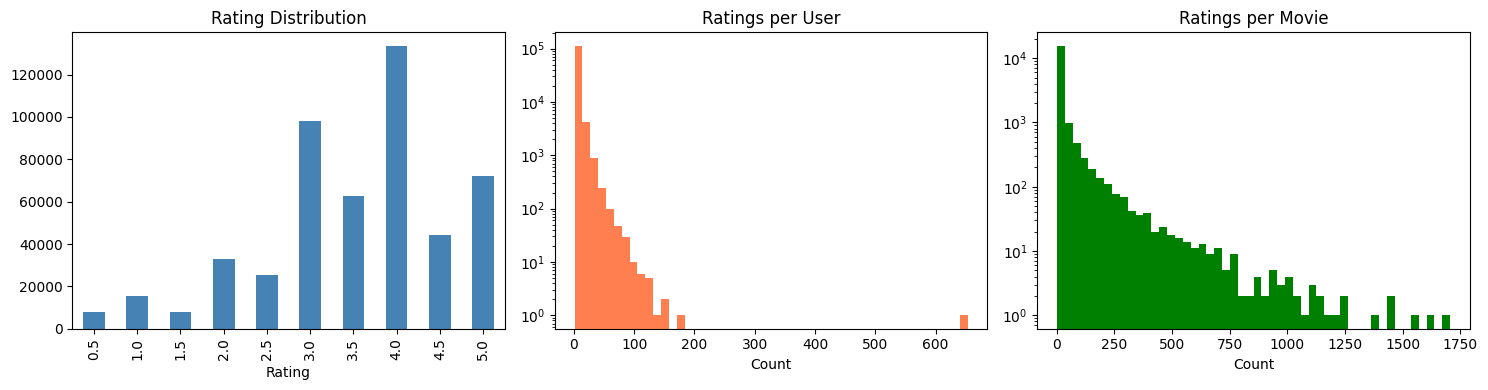

Missing values:
user_idx              0
movie_idx             0
rating                0
final_genres_str     21
meta_vote_average     0
meta_vote_count       0
meta_popularity       0
meta_runtime          0
release_year         22
dtype: int64


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')

ratings_per_user = df.groupby('user_idx').size()
axes[1].hist(ratings_per_user, bins=50, color='coral', log=True)
axes[1].set_title('Ratings per User')
axes[1].set_xlabel('Count')

ratings_per_movie = df.groupby('movie_idx').size()
axes[2].hist(ratings_per_movie, bins=50, color='green', log=True)
axes[2].set_title('Ratings per Movie')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

print('Missing values:')
print(df[['user_idx','movie_idx','rating','final_genres_str',
          'meta_vote_average','meta_vote_count','meta_popularity',
          'meta_runtime','release_year']].isnull().sum())


## Metadata Features

The multimodal model needs fixed-length side features for each movie. Here, genres become one-hot columns and numeric TMDB fields become scaled numeric features.


In [39]:
movie_features = df[['movie_idx','final_genres_str','meta_vote_average',
                      'meta_vote_count','meta_popularity',
                      'meta_runtime','release_year']].drop_duplicates('movie_idx').copy()

movie_features['final_genres_str'] = movie_features['final_genres_str'].fillna('')
genre_lists = movie_features['final_genres_str'].apply(lambda x: x.split('|') if x else ['Unknown'])

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(genre_lists)

print(f'Genres found ({len(mlb.classes_)}):', list(mlb.classes_))
print(f'Genre matrix shape: {genre_matrix.shape}')


Genres found (28): ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'IMAX', 'Music', 'Mystery', 'News', 'Noir', 'Romance', 'Science Fiction', 'Short', 'Sport', 'TV Movie', 'Talk-Show', 'Thriller', 'Unknown', 'War', 'Western']
Genre matrix shape: (18239, 28)


In [40]:
numeric_cols = ['meta_vote_average', 'meta_vote_count', 'meta_popularity',
                'meta_runtime', 'release_year']

for col in numeric_cols:
    movie_features[col] = pd.to_numeric(movie_features[col], errors='coerce')

for col in ['meta_vote_count', 'meta_popularity']:
    movie_features[col] = np.log1p(movie_features[col].clip(lower=0))

for col in numeric_cols:
    median = movie_features[col].median()
    fill_value = 0.0 if pd.isna(median) else median
    movie_features[col] = movie_features[col].fillna(fill_value)

scaler = MinMaxScaler()
numeric_matrix = scaler.fit_transform(movie_features[numeric_cols])

metadata_matrix = np.hstack([genre_matrix, numeric_matrix]).astype(np.float32)
metadata_feature_names = list(mlb.classes_) + numeric_cols
metadata_feature_groups = [(name, [idx]) for idx, name in enumerate(metadata_feature_names)]
META_DIM = metadata_matrix.shape[1]

print(f'Metadata vector dimension: {META_DIM}  (genres={genre_matrix.shape[1]}, numerics={numeric_matrix.shape[1]})')
print('Numeric metadata columns:', numeric_cols)

meta_idx_array = movie_features['movie_idx'].values
meta_lookup = np.zeros((N_MOVIES, META_DIM), dtype=np.float32)
meta_lookup[meta_idx_array] = metadata_matrix

print(f'meta_lookup shape: {meta_lookup.shape}')


Metadata vector dimension: 33  (genres=28, numerics=5)
Numeric metadata columns: ['meta_vote_average', 'meta_vote_count', 'meta_popularity', 'meta_runtime', 'release_year']
meta_lookup shape: (62423, 33)


## Split

The loaded rating rows are split into train/validation/test sets: 80% for fitting, 10% for early stopping and residual tuning, and 10% for final reporting.


In [41]:
user_arr   = df['user_idx'].values.astype(np.int32)
movie_arr  = df['movie_idx'].values.astype(np.int32)
rating_arr = df['rating'].values.astype(np.float32)

idx = np.arange(len(df))
train_idx, temp_idx = train_test_split(idx, test_size=0.2, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED)

print(f'Train size : {len(train_idx):,}')
print(f'Val size   : {len(val_idx):,}')
print(f'Test size  : {len(test_idx):,}')


def make_inputs(idx_set):
    u = user_arr[idx_set]
    m = movie_arr[idx_set]
    r = rating_arr[idx_set]
    meta = meta_lookup[m]
    poster = poster_embeddings[m]
    return u, m, r, meta, poster


u_train, m_train, r_train, meta_train, poster_train = make_inputs(train_idx)
u_val,   m_val,   r_val,   meta_val,   poster_val   = make_inputs(val_idx)
u_test,  m_test,  r_test,  meta_test,  poster_test  = make_inputs(test_idx)

print('\nInput shapes (train):')
print(f'  users  : {u_train.shape}')
print(f'  movies : {m_train.shape}')
print(f'  ratings: {r_train.shape}')
print(f'  meta   : {meta_train.shape}')
print(f'  poster : {poster_train.shape}')


Train size : 400,000
Val size   : 50,000
Test size  : 50,000

Input shapes (train):
  users  : (400000,)
  movies : (400000,)
  ratings: (400000,)
  meta   : (400000, 33)
  poster : (400000, 65)


## Evaluation

RMSE and MAE are the main metrics. RMSE penalizes large mistakes more strongly, while MAE is easier to read as average rating error.


In [42]:
def predict_ratings(model, inputs_dict, batch_size=BATCH_SIZE):
    y_pred = model.predict(inputs_dict, batch_size=batch_size, verbose=0).flatten()
    return np.clip(y_pred, RATING_MIN, RATING_MAX)


def metric_dict(y_true, y_pred):
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
    }


def evaluate_model(model, inputs_dict, y_true, model_name):
    y_pred = predict_ratings(model, inputs_dict)
    metrics = metric_dict(y_true, y_pred)
    print(f'[{model_name}]  RMSE = {metrics["RMSE"]:.4f}  |  MAE = {metrics["MAE"]:.4f}')
    return metrics['RMSE'], metrics['MAE'], y_pred


results = {}
test_predictions = {}


## Traditional User-Based CF

This baseline predicts from the ratings of similar users. It builds a sparse user-item matrix from the training split only, computes cosine similarity on user-centered ratings, then uses the top similar users who rated the target movie.


In [43]:
class UserBasedCF:
    def __init__(self, n_users, n_movies, top_k=50, min_similarity=1e-6):
        self.n_users = int(n_users)
        self.n_movies = int(n_movies)
        self.top_k = int(top_k)
        self.min_similarity = float(min_similarity)

    def fit(self, users, movies, ratings):
        users = np.asarray(users, dtype=np.int32)
        movies = np.asarray(movies, dtype=np.int32)
        ratings = np.asarray(ratings, dtype=np.float32)

        self.global_mean = float(ratings.mean())

        user_sum = np.bincount(users, weights=ratings, minlength=self.n_users).astype(np.float32)
        movie_sum = np.bincount(movies, weights=ratings, minlength=self.n_movies).astype(np.float32)
        self.user_count = np.bincount(users, minlength=self.n_users).astype(np.int32)
        self.movie_count = np.bincount(movies, minlength=self.n_movies).astype(np.int32)

        self.user_mean = np.full(self.n_users, self.global_mean, dtype=np.float32)
        known_users = self.user_count > 0
        self.user_mean[known_users] = user_sum[known_users] / self.user_count[known_users]

        self.movie_mean = np.full(self.n_movies, self.global_mean, dtype=np.float32)
        known_movies = self.movie_count > 0
        self.movie_mean[known_movies] = movie_sum[known_movies] / self.movie_count[known_movies]

        centered = ratings - self.user_mean[users]
        shape = (self.n_users, self.n_movies)
        self.deviation_matrix = sparse.csr_matrix((centered, (users, movies)), shape=shape, dtype=np.float32)
        self.deviation_by_movie = self.deviation_matrix.tocsc()

        row_norm = np.sqrt(np.asarray(self.deviation_matrix.multiply(self.deviation_matrix).sum(axis=1)).ravel())
        self.normalized_deviation = self.deviation_matrix.copy().tocsr()
        row_ids = np.repeat(np.arange(self.n_users), np.diff(self.normalized_deviation.indptr))
        valid = row_norm[row_ids] > 0
        self.normalized_deviation.data[valid] /= row_norm[row_ids[valid]]
        self.normalized_deviation.data[~valid] = 0.0
        self.normalized_deviation.eliminate_zeros()
        return self

    def _fallback_predictions(self, users, movies):
        preds = np.full(len(users), self.global_mean, dtype=np.float32)
        user_known = self.user_count[users] > 0
        movie_known = self.movie_count[movies] > 0

        both_known = user_known & movie_known
        preds[both_known] = 0.5 * self.user_mean[users[both_known]] + 0.5 * self.movie_mean[movies[both_known]]

        only_user = user_known & ~movie_known
        preds[only_user] = self.user_mean[users[only_user]]

        only_movie = ~user_known & movie_known
        preds[only_movie] = self.movie_mean[movies[only_movie]]
        return preds

    def predict(self, users, movies):
        users = np.asarray(users, dtype=np.int32)
        movies = np.asarray(movies, dtype=np.int32)
        preds = self._fallback_predictions(users, movies)
        if len(users) == 0:
            return preds

        order = np.argsort(movies, kind='stable')
        movie_breaks = np.flatnonzero(np.diff(movies[order])) + 1
        for pred_positions in np.split(order, movie_breaks):
            movie_id = int(movies[pred_positions[0]])
            movie_col = self.deviation_by_movie.getcol(movie_id)
            neighbor_users = movie_col.indices.astype(np.int32, copy=False)
            neighbor_devs = movie_col.data.astype(np.float32, copy=False)
            if len(neighbor_users) == 0:
                continue

            target_users = users[pred_positions]
            similarities = self.normalized_deviation[target_users].dot(
                self.normalized_deviation[neighbor_users].T
            ).toarray().astype(np.float32, copy=False)
            similarities[similarities < self.min_similarity] = 0.0

            neighbor_lookup = {int(user_id): pos for pos, user_id in enumerate(neighbor_users)}
            for row_pos, target_user in enumerate(target_users):
                same_user_pos = neighbor_lookup.get(int(target_user))
                if same_user_pos is not None:
                    similarities[row_pos, same_user_pos] = 0.0

            for row_pos, pred_pos in enumerate(pred_positions):
                weights = similarities[row_pos]
                neighbor_pos = np.flatnonzero(weights > 0)
                if len(neighbor_pos) == 0:
                    continue
                if len(neighbor_pos) > self.top_k:
                    top_local = np.argpartition(weights[neighbor_pos], -self.top_k)[-self.top_k:]
                    neighbor_pos = neighbor_pos[top_local]

                top_weights = weights[neighbor_pos]
                denom = np.abs(top_weights).sum()
                if denom > 0:
                    preds[pred_pos] = self.user_mean[users[pred_pos]] + np.dot(top_weights, neighbor_devs[neighbor_pos]) / denom

        return np.clip(preds, RATING_MIN, RATING_MAX)


user_cf_model = UserBasedCF(N_USERS, N_MOVIES, top_k=50)
user_cf_model.fit(u_train, m_train, r_train)

user_cf_test_pred = user_cf_model.predict(u_test, m_test)
user_cf_metrics = metric_dict(r_test, user_cf_test_pred)
print(f'[User-Based CF]  RMSE = {user_cf_metrics["RMSE"]:.4f}  |  MAE = {user_cf_metrics["MAE"]:.4f}')
print(f'CF training ratings: {len(r_train):,}; active users: {(user_cf_model.user_count > 0).sum():,}; active movies: {(user_cf_model.movie_count > 0).sum():,}')

results['User-Based CF'] = user_cf_metrics
test_predictions['User-Based CF'] = user_cf_test_pred


[User-Based CF]  RMSE = 1.0374  |  MAE = 0.8021
CF training ratings: 400,000; active users: 109,560; active movies: 16,886


## Baseline Model

The baseline neural collaborative filtering model learns a vector for each user and movie, concatenates them, and predicts the rating from interaction history only. This is the reference model.


In [44]:
def build_baseline_model(n_users, n_movies, embed_dim=EMBEDDING_DIM):
    user_input  = keras.Input(shape=(1,), name='user_idx',  dtype='int32')
    movie_input = keras.Input(shape=(1,), name='movie_idx', dtype='int32')

    user_emb = layers.Embedding(
        input_dim=n_users,
        output_dim=embed_dim,
        embeddings_regularizer=keras.regularizers.l2(1e-6),
        name='user_embedding'
    )(user_input)
    user_emb = layers.Flatten(name='user_flatten')(user_emb)

    movie_emb = layers.Embedding(
        input_dim=n_movies,
        output_dim=embed_dim,
        embeddings_regularizer=keras.regularizers.l2(1e-6),
        name='movie_embedding'
    )(movie_input)
    movie_emb = layers.Flatten(name='movie_flatten')(movie_emb)

    x = layers.Concatenate(name='cf_features')([user_emb, movie_emb])
    x = layers.Dense(64, activation='relu', name='cf_dense_1')(x)
    x = layers.Dropout(0.3, name='cf_dropout_1')(x)
    x = layers.Dense(32, activation='relu', name='cf_dense_2')(x)
    output = layers.Dense(1, name='rating_output')(x)

    model = Model(inputs=[user_input, movie_input], outputs=output, name='Baseline_NCF')
    return model


baseline_model = build_baseline_model(N_USERS, N_MOVIES)
baseline_model.summary()

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)


Model: "Baseline_NCF"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_idx            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_idx           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │  5,201,312 │ user_idx[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 32)     │  1,997,536 │ movie_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_flatten        │ (None, 32)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_flatten       │ (None, 32)        │          0 │ movie_embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_features         │ (None, 64)        │          0 │ user_flatten[0][… │
│ (Concatenate)       │                   │            │ movie_flatten[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_dense_1 (Dense)  │ (None, 64)        │      4,160 │ cf_features[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_dropout_1        │ (None, 64)        │          0 │ cf_dense_1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_dense_2 (Dense)  │ (None, 32)        │      2,080 │ cf_dropout_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_output       │ (None, 1)         │         33 │ cf_dense_2[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,205,121 (27.49 MB)

 Trainable params: 7,205,121 (27.49 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history_baseline = baseline_model.fit(
    x={'user_idx': u_train, 'movie_idx': m_train},
    y=r_train,
    validation_data=(
        {'user_idx': u_val, 'movie_idx': m_val},
        r_val
    ),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_BASELINE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 55s 137ms/step - loss: 2.3478 - mae: 1.1254 - val_loss: 0.8912 - val_mae: 0.7312
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 121ms/step - loss: 0.8476 - mae: 0.7140 - val_loss: 0.9094 - val_mae: 0.7377
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - loss: 0.6892 - mae: 0.6366 - val_loss: 0.9758 - val_mae: 0.7622
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 45s 116ms/step - loss: 0.5813 - mae: 0.5787 - val_loss: 1.0192 - val_mae: 0.7776


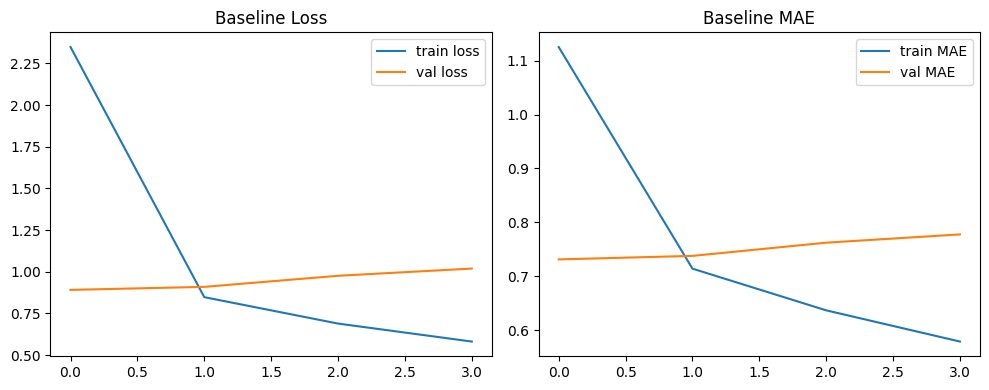

In [46]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'],     label='train loss')
plt.plot(history_baseline.history['val_loss'], label='val loss')
plt.title('Baseline Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['mae'],     label='train MAE')
plt.plot(history_baseline.history['val_mae'], label='val MAE')
plt.title('Baseline MAE')
plt.legend()
plt.tight_layout()
plt.show()


In [47]:
rmse_b, mae_b, baseline_test_pred = evaluate_model(
    baseline_model,
    {'user_idx': u_test, 'movie_idx': m_test},
    r_test,
    model_name='Baseline NCF'
)
results['Baseline NCF'] = {'RMSE': rmse_b, 'MAE': mae_b}
test_predictions['Baseline NCF'] = baseline_test_pred


[Baseline NCF]  RMSE = 0.9446  |  MAE = 0.7328


## Multimodal Model

The multimodal model copies the trained baseline weights, freezes that collaborative branch first, and trains a small residual branch from movie metadata and poster features. After that, it keeps the best residual strength on validation data.


### Diagnostics

These checks show how much poster signal is actually available and whether poster features have any simple relationship with average movie ratings.


In [48]:
zero_poster_mask = ~poster_available
print(f'Movies with all-zero raw poster embeddings: {zero_poster_mask.sum()} / {len(poster_available)}')
print(f'Poster model matrix: shape={poster_embeddings.shape}, mean={poster_embeddings[:, :-1].mean():.3f}, std={poster_embeddings[:, :-1].std():.3f}')

rv = df.groupby('movie_idx')['rating'].agg(['var', 'count'])
print('\nPer-movie rating variance:')
print(f'  Mean   : {rv["var"].mean():.4f}')
print(f'  Median : {rv["var"].median():.4f}')
print(f'  Movies with variance > 1.0 : {(rv["var"] > 1.0).sum()} / {len(rv)}')

sample_idxs = df['movie_idx'].unique()
available_sample = sample_idxs[poster_available[sample_idxs]]
if len(available_sample) > 2 and poster_embeddings.shape[1] > 2:
    poster_signal = poster_embeddings[available_sample, :-1]
    svd_diag = TruncatedSVD(n_components=1, random_state=SEED)
    poster_pc1 = svd_diag.fit_transform(poster_signal).flatten()
    avg_rating = df.groupby('movie_idx')['rating'].mean().loc[available_sample].values
    corr = np.corrcoef(poster_pc1, avg_rating)[0, 1]
    print(f'\nPearson corr(poster PC1, avg movie rating) = {corr:.4f}')
else:
    print('\nNot enough available posters for PC1 correlation diagnostic.')

print(f'\nBaseline trainable params: {baseline_model.count_params():,}')


Movies with all-zero raw poster embeddings: 1284 / 62423
Poster model matrix: shape=(62423, 65), mean=-0.000, std=0.990

Per-movie rating variance:
  Mean   : 0.9930
  Median : 0.8282
  Movies with variance > 1.0 : 4453 / 18239

Pearson corr(poster PC1, avg movie rating) = 0.0077

Baseline trainable params: 7,205,121


In [49]:
def build_multimodal_model(n_users, n_movies, meta_dim, poster_dim, embed_dim=EMBEDDING_DIM):
    user_input   = keras.Input(shape=(1,),          name='user_idx',   dtype='int32')
    movie_input  = keras.Input(shape=(1,),          name='movie_idx',  dtype='int32')
    meta_input   = keras.Input(shape=(meta_dim,),   name='metadata')
    poster_input = keras.Input(shape=(poster_dim,), name='poster_emb')

    user_emb = layers.Embedding(
        n_users, embed_dim,
        embeddings_regularizer=keras.regularizers.l2(1e-6),
        name='user_embedding'
    )(user_input)
    user_emb = layers.Flatten(name='user_flatten')(user_emb)

    movie_emb = layers.Embedding(
        n_movies, embed_dim,
        embeddings_regularizer=keras.regularizers.l2(1e-6),
        name='movie_embedding'
    )(movie_input)
    movie_emb = layers.Flatten(name='movie_flatten')(movie_emb)

    cf = layers.Concatenate(name='cf_features')([user_emb, movie_emb])
    cf = layers.Dense(64, activation='relu', name='cf_dense_1')(cf)
    cf = layers.Dense(32, activation='relu', name='cf_dense_2')(cf)
    cf_rating = layers.Dense(1, name='cf_rating')(cf)

    meta = layers.BatchNormalization(name='meta_bn')(meta_input)
    meta = layers.Dense(
        16,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='meta_dense_1'
    )(meta)
    meta = layers.Dropout(0.15, name='meta_dropout_1')(meta)

    poster = layers.BatchNormalization(name='poster_bn')(poster_input)
    poster = layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='poster_dense_1'
    )(poster)
    poster = layers.Dropout(0.25, name='poster_dropout_1')(poster)

    side = layers.Concatenate(name='side_features')([meta, poster])
    side = layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='side_dense_1'
    )(side)
    side = layers.Dropout(0.20, name='side_dropout_1')(side)
    residual = layers.Dense(
        1,
        kernel_initializer='zeros',
        bias_initializer='zeros',
        name='side_residual'
    )(side)

    output = layers.Add(name='rating_output')([cf_rating, residual])
    model = Model(
        inputs=[user_input, movie_input, meta_input, poster_input],
        outputs=output,
        name='Multimodal_NCF_residual'
    )
    return model


def copy_baseline_to_multimodal(baseline, multimodal):
    layer_pairs = {
        'user_embedding': 'user_embedding',
        'movie_embedding': 'movie_embedding',
        'cf_dense_1': 'cf_dense_1',
        'cf_dense_2': 'cf_dense_2',
        'rating_output': 'cf_rating',
    }
    for src_name, dst_name in layer_pairs.items():
        multimodal.get_layer(dst_name).set_weights(baseline.get_layer(src_name).get_weights())


def set_collaborative_trainable(model, trainable):
    for name in ['user_embedding', 'movie_embedding', 'cf_dense_1', 'cf_dense_2', 'cf_rating']:
        model.get_layer(name).trainable = trainable


multi_model = build_multimodal_model(N_USERS, N_MOVIES, META_DIM, POSTER_DIM)
copy_baseline_to_multimodal(baseline_model, multi_model)
set_collaborative_trainable(multi_model, False)

multi_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss='mse',
    metrics=['mae']
)

multi_model.summary()
print(f'Multimodal params: total={multi_model.count_params():,}, trainable side branch only')


Model: "Multimodal_NCF_residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ metadata            │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poster_emb          │ (None, 65)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_idx            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_idx           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_bn             │ (None, 33)        │        132 │ metadata[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poster_bn           │ (None, 65)        │        260 │ poster_emb[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │  5,201,312 │ user_idx[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 32)     │  1,997,536 │ movie_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_dense_1        │ (None, 16)        │        544 │ meta_bn[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poster_dense_1      │ (None, 32)        │      2,112 │ poster_bn[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_flatten        │ (None, 32)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_flatten       │ (None, 32)        │          0 │ movie_embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_dropout_1      │ (None, 16)        │          0 │ meta_dense_1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poster_dropout_1    │ (None, 32)        │          0 │ poster_dense_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_features         │ (None, 64)        │          0 │ user_flatten[0][… │
│ (Concatenate)       │                   │            │ movie_flatten[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ side_features       │ (None, 48)        │          0 │ meta_dropout_1[0… │
│ (Concatenate)       │                   │            │ poster_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_dense_1 (Dense)  │ (None, 64)        │      4,160 │ cf_features[0][0

 Total params: 7,209,770 (27.50 MB)

 Trainable params: 4,453 (17.39 KB)

 Non-trainable params: 7,205,317 (27.49 MB)

Multimodal params: total=7,209,770, trainable side branch only


In [50]:
multi_train_inputs = {
    'user_idx'  : u_train,
    'movie_idx' : m_train,
    'metadata'  : meta_train,
    'poster_emb': poster_train,
}
multi_val_inputs = {
    'user_idx'  : u_val,
    'movie_idx' : m_val,
    'metadata'  : meta_val,
    'poster_emb': poster_val,
}

initial_weights = multi_model.get_weights()
initial_val_pred = multi_model.predict(multi_val_inputs, batch_size=BATCH_SIZE, verbose=0).flatten()
initial_val_pred = np.clip(initial_val_pred, RATING_MIN, RATING_MAX)
initial_val_rmse = np.sqrt(mean_squared_error(r_val, initial_val_pred))
print(f'Initial multimodal validation RMSE (baseline-equivalent): {initial_val_rmse:.4f}')

early_stop_multi = keras.callbacks.EarlyStopping(
    monitor='val_mae', mode='min', patience=4, restore_best_weights=True
)
reduce_lr_multi = keras.callbacks.ReduceLROnPlateau(
    monitor='val_mae', mode='min', factor=0.5, patience=2, min_lr=1e-6, verbose=1
)

history_multi = multi_model.fit(
    x=multi_train_inputs,
    y=r_train,
    validation_data=(multi_val_inputs, r_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_MULTI,
    callbacks=[early_stop_multi, reduce_lr_multi],
    verbose=1
)

trained_weights = multi_model.get_weights()
alpha_grid = np.linspace(0.0, 1.0, 21)
best_alpha = 0.0
best_val_rmse = initial_val_rmse
best_weights = initial_weights

for alpha in alpha_grid[1:]:
    multi_model.set_weights(trained_weights)
    residual_layer = multi_model.get_layer('side_residual')
    residual_weights = residual_layer.get_weights()
    residual_layer.set_weights([residual_weights[0] * alpha, residual_weights[1] * alpha])

    val_pred = multi_model.predict(multi_val_inputs, batch_size=BATCH_SIZE, verbose=0).flatten()
    val_pred = np.clip(val_pred, RATING_MIN, RATING_MAX)
    val_rmse = np.sqrt(mean_squared_error(r_val, val_pred))
    if val_rmse < best_val_rmse - 1e-5:
        best_alpha = float(alpha)
        best_val_rmse = float(val_rmse)
        best_weights = multi_model.get_weights()

multi_model.set_weights(best_weights)
if best_alpha == 0.0:
    print('Side residual did not improve validation RMSE; restored baseline-equivalent multimodal weights.')
else:
    print(f'Best residual alpha on validation: {best_alpha:.2f} (RMSE {best_val_rmse:.4f})')


Initial multimodal validation RMSE (baseline-equivalent): 0.9427
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.7462 - mae: 0.6585 - val_loss: 0.8894 - val_mae: 0.7289 - learning_rate: 0.0010
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7413 - mae: 0.6570 - val_loss: 0.8854 - val_mae: 0.7283 - learning_rate: 0.0010
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7394 - mae: 0.6564 - val_loss: 0.8838 - val_mae: 0.7280 - learning_rate: 0.0010
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7383 - mae: 0.6562 - val_loss: 0.8834 - val_mae: 0.7282 - learning_rate: 0.0010
Epoch 5/20
380/391 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8067 - mae: 0.6890
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7376 - mae: 0.6560 - val_loss: 0.8832 - val_mae: 0.7282 - learning_rate: 0.0010
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7369 - mae: 0.655

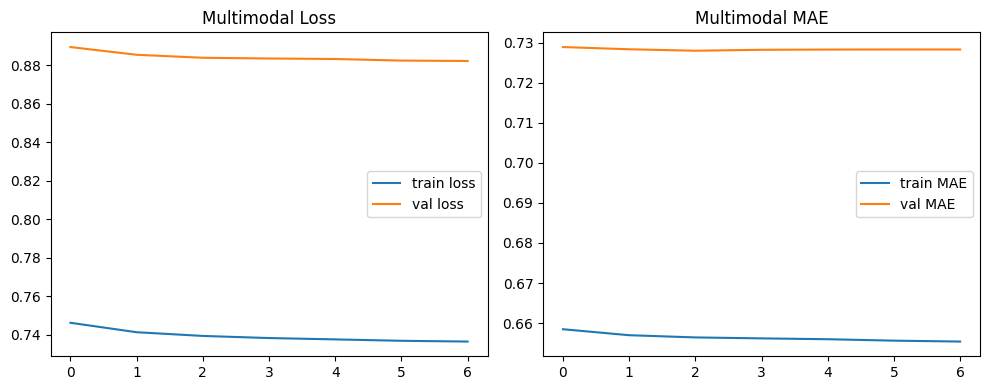

In [51]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_multi.history['loss'],     label='train loss')
plt.plot(history_multi.history['val_loss'], label='val loss')
plt.title('Multimodal Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_multi.history['mae'],     label='train MAE')
plt.plot(history_multi.history['val_mae'], label='val MAE')
plt.title('Multimodal MAE')
plt.legend()
plt.tight_layout()
plt.show()


In [52]:
multi_test_inputs = {
    'user_idx'  : u_test,
    'movie_idx' : m_test,
    'metadata'  : meta_test,
    'poster_emb': poster_test
}

rmse_m, mae_m, multi_test_pred = evaluate_model(
    multi_model,
    multi_test_inputs,
    r_test,
    model_name='Multimodal NCF'
)
results['Multimodal NCF'] = {'RMSE': rmse_m, 'MAE': mae_m}
test_predictions['Multimodal NCF'] = multi_test_pred


[Multimodal NCF]  RMSE = 0.9414  |  MAE = 0.7296


## Comparison

This section compares the traditional CF baseline and the neural models on the held-out test set, then prints the architecture differences that are useful for slides.



=== Model Comparison (Test Set) ===
                 RMSE    MAE  RMSE_improvement_%  MAE_improvement_%
User-Based CF  1.0374 0.8021             -9.8200            -9.4700
Baseline NCF   0.9446 0.7328              0.0000             0.0000
Multimodal NCF 0.9414 0.7296              0.3400             0.4300


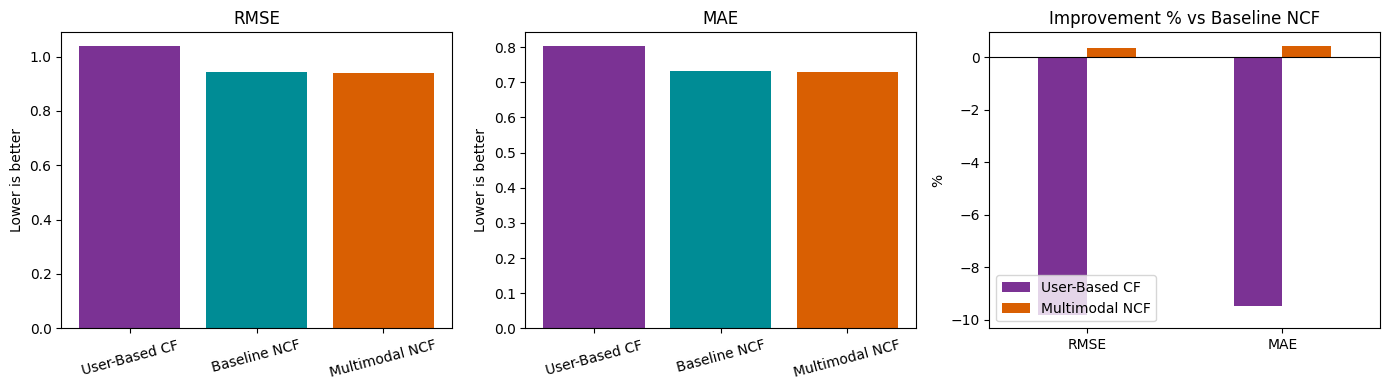


=== Architecture Comparison ===
                            User Embedding             Movie Embedding               Metadata                           Poster CNN Total Params Trainable Params
Model                                                                                                                                                           
User-Based CF                           No                          No                     No                                   No            0                0
Baseline NCF                  Yes (32-dim)                Yes (32-dim)                     No                                   No    7,205,121        7,205,121
Multimodal NCF  Yes (32-dim, warm-started)  Yes (32-dim, warm-started)  Yes (33-dim residual)  Yes (64 visual + availability flag)    7,209,770            4,453


In [53]:
comparison_df = pd.DataFrame(results).T
comparison_df['RMSE_improvement_%'] = (
    (comparison_df.loc['Baseline NCF', 'RMSE'] - comparison_df['RMSE'])
    / comparison_df.loc['Baseline NCF', 'RMSE'] * 100
).round(2)
comparison_df['MAE_improvement_%'] = (
    (comparison_df.loc['Baseline NCF', 'MAE'] - comparison_df['MAE'])
    / comparison_df.loc['Baseline NCF', 'MAE'] * 100
).round(2)

print('\n=== Model Comparison (Test Set) ===')
print(comparison_df.to_string(float_format='{:.4f}'.format))

model_colors = {
    'User-Based CF': '#7b3294',
    'Baseline NCF': '#008c95',
    'Multimodal NCF': '#d95f02',
}
bar_colors = [model_colors.get(name, 'gray') for name in comparison_df.index]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(comparison_df.index, comparison_df['RMSE'], color=bar_colors)
axes[0].set_title('RMSE')
axes[0].set_ylabel('Lower is better')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(comparison_df.index, comparison_df['MAE'], color=bar_colors)
axes[1].set_title('MAE')
axes[1].set_ylabel('Lower is better')
axes[1].tick_params(axis='x', rotation=15)

improvement_cols = ['RMSE_improvement_%', 'MAE_improvement_%']
improvement_models = [name for name in comparison_df.index if name != 'Baseline NCF']
comparison_df.loc[improvement_models, improvement_cols].T.plot(
    kind='bar',
    ax=axes[2],
    color=[model_colors.get(name, 'gray') for name in improvement_models],
)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Improvement % vs Baseline NCF')
axes[2].set_ylabel('%')
axes[2].set_xticklabels(['RMSE', 'MAE'], rotation=0)
axes[2].legend(title='')
plt.tight_layout()
plt.show()


def trainable_param_count(model):
    return int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))

arch_df = pd.DataFrame({
    'Model': ['User-Based CF', 'Baseline NCF', 'Multimodal NCF'],
    'User Embedding': ['No', f'Yes ({EMBEDDING_DIM}-dim)', f'Yes ({EMBEDDING_DIM}-dim, warm-started)'],
    'Movie Embedding': ['No', f'Yes ({EMBEDDING_DIM}-dim)', f'Yes ({EMBEDDING_DIM}-dim, warm-started)'],
    'Metadata': ['No', 'No', f'Yes ({META_DIM}-dim residual)'],
    'Poster CNN': ['No', 'No', f'Yes ({POSTER_DIM - 1} visual + availability flag)'],
    'Total Params': ['0', f'{baseline_model.count_params():,}', f'{multi_model.count_params():,}'],
    'Trainable Params': ['0', f'{trainable_param_count(baseline_model):,}', f'{trainable_param_count(multi_model):,}'],
}).set_index('Model')

print('\n=== Architecture Comparison ===')
print(arch_df.to_string())


## Model Behavior Visualizations

These plots explain how the models behave, not only which one has the lower average error. They compare prediction errors, rating-bucket MAE, and whether each newer model reduces per-rating absolute error against the previous baseline.


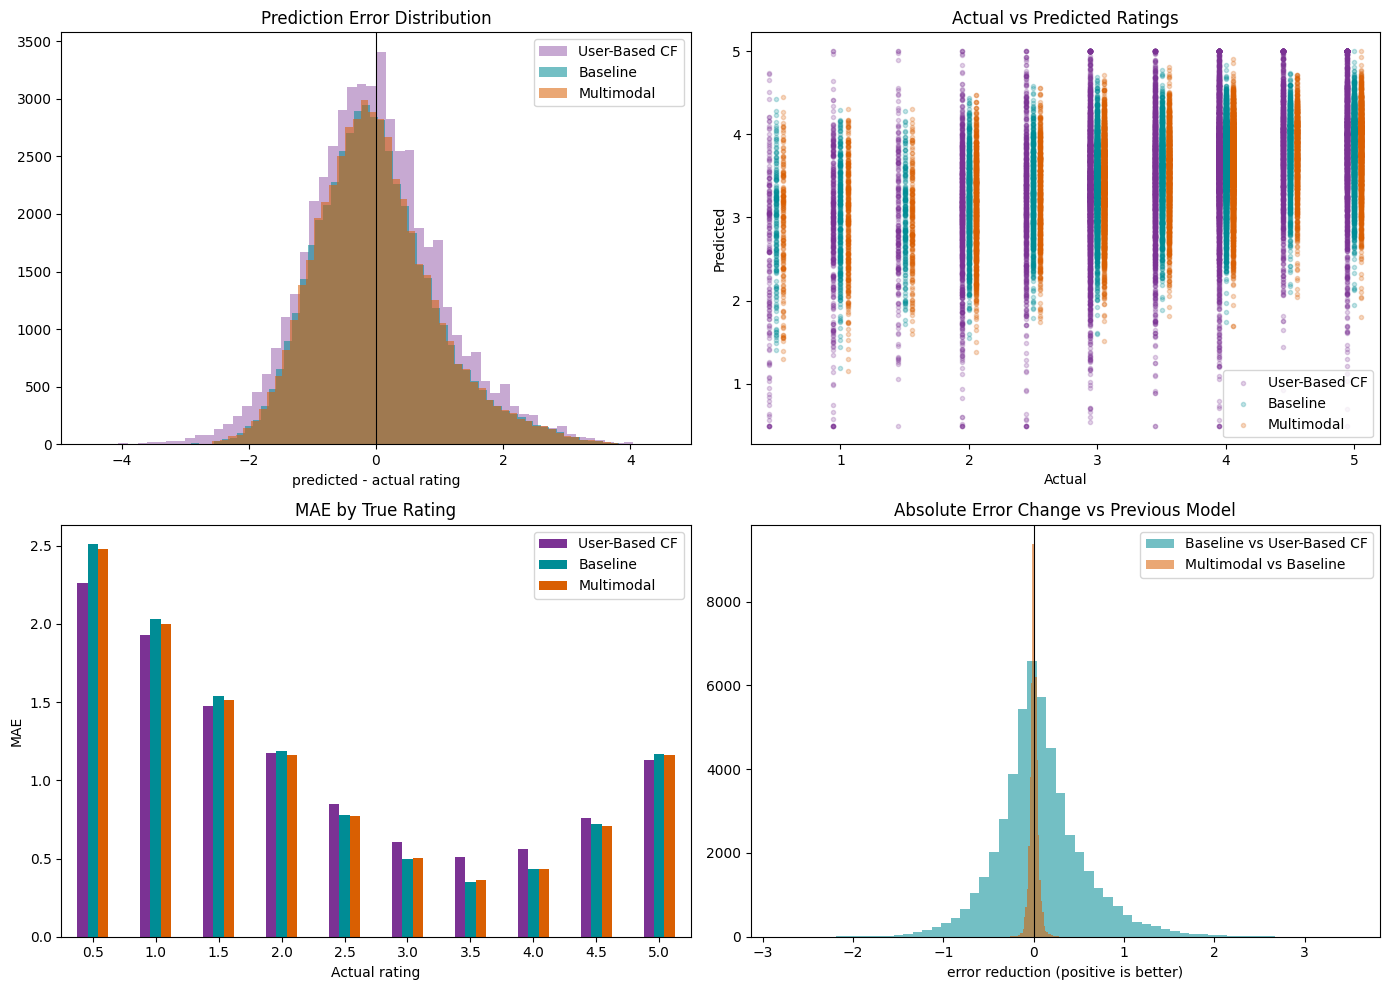

Positive abs_error_delta means multimodal reduced absolute error vs Baseline NCF.
Positive cf_to_baseline_abs_error_delta means Baseline NCF reduced absolute error vs User-Based CF.
       user_cf_abs_error  baseline_abs_error  multimodal_abs_error  \
count         50000.0000          50000.0000            50000.0000   
mean              0.8021              0.7328                0.7296   
std               0.6579              0.5961                0.5949   
min               0.0000              0.0000                0.0000   
25%               0.3000              0.2740                0.2728   
50%               0.6458              0.5949                0.5926   
75%               1.1256              1.0389                1.0333   
max               4.5000              4.1895                4.1806   

       cf_to_baseline_abs_error_delta  abs_error_delta  
count                      50000.0000       50000.0000  
mean                           0.0694           0.0032  
std             

In [59]:
eval_df = pd.DataFrame({
    'user_idx': u_test,
    'movie_idx': m_test,
    'actual': r_test,
    'user_cf_pred': test_predictions['User-Based CF'],
    'baseline_pred': test_predictions['Baseline NCF'],
    'multimodal_pred': test_predictions['Multimodal NCF'],
})
eval_df['user_cf_error'] = eval_df['user_cf_pred'] - eval_df['actual']
eval_df['baseline_error'] = eval_df['baseline_pred'] - eval_df['actual']
eval_df['multimodal_error'] = eval_df['multimodal_pred'] - eval_df['actual']
eval_df['user_cf_abs_error'] = eval_df['user_cf_error'].abs()
eval_df['baseline_abs_error'] = eval_df['baseline_error'].abs()
eval_df['multimodal_abs_error'] = eval_df['multimodal_error'].abs()
eval_df['abs_error_delta'] = eval_df['baseline_abs_error'] - eval_df['multimodal_abs_error']
eval_df['cf_to_baseline_abs_error_delta'] = eval_df['user_cf_abs_error'] - eval_df['baseline_abs_error']
eval_df['poster_available'] = poster_available[eval_df['movie_idx'].values]

user_activity = df.groupby('user_idx').size()
movie_activity = df.groupby('movie_idx').size()
eval_df['user_activity'] = eval_df['user_idx'].map(user_activity).fillna(0).astype(int)
eval_df['movie_activity'] = eval_df['movie_idx'].map(movie_activity).fillna(0).astype(int)
rating_categories = sorted(pd.Series(eval_df['actual']).unique())
eval_df['rating_bucket'] = pd.Categorical(eval_df['actual'], categories=rating_categories, ordered=True)

def activity_bins(values, labels):
    if len(values) < len(labels):
        return pd.Series(['all'] * len(values), index=values.index)
    try:
        return pd.qcut(values.rank(method='first'), q=len(labels), labels=labels)
    except ValueError:
        return pd.Series(['all'] * len(values), index=values.index)

eval_df['user_activity_bin'] = activity_bins(eval_df['user_activity'], ['low', 'mid-low', 'mid-high', 'high'])
eval_df['movie_activity_bin'] = activity_bins(eval_df['movie_activity'], ['niche', 'mid-niche', 'mid-popular', 'popular'])

behavior_colors = {
    'User-Based CF': '#7b3294',
    'Baseline NCF': '#008c95',
    'Multimodal NCF': '#d95f02',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(eval_df['user_cf_error'], bins=60, alpha=0.42, label='User-Based CF', color=behavior_colors['User-Based CF'])
axes[0, 0].hist(eval_df['baseline_error'], bins=60, alpha=0.55, label='Baseline', color=behavior_colors['Baseline NCF'])
axes[0, 0].hist(eval_df['multimodal_error'], bins=60, alpha=0.55, label='Multimodal', color=behavior_colors['Multimodal NCF'])
axes[0, 0].axvline(0, color='black', linewidth=0.8)
axes[0, 0].set_title('Prediction Error Distribution')
axes[0, 0].set_xlabel('predicted - actual rating')
axes[0, 0].legend()

sample_plot = eval_df.sample(n=min(12000, len(eval_df)), random_state=SEED)
x_offsets = {'User-Based CF': -0.055, 'Baseline NCF': 0.0, 'Multimodal NCF': 0.055}
axes[0, 1].scatter(sample_plot['actual'] + x_offsets['User-Based CF'], sample_plot['user_cf_pred'], s=9, alpha=0.22, label='User-Based CF', color=behavior_colors['User-Based CF'])
axes[0, 1].scatter(sample_plot['actual'] + x_offsets['Baseline NCF'], sample_plot['baseline_pred'], s=9, alpha=0.24, label='Baseline', color=behavior_colors['Baseline NCF'])
axes[0, 1].scatter(sample_plot['actual'] + x_offsets['Multimodal NCF'], sample_plot['multimodal_pred'], s=9, alpha=0.24, label='Multimodal', color=behavior_colors['Multimodal NCF'])
axes[0, 1].set_title('Actual vs Predicted Ratings')
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_xlim(RATING_MIN - 0.2, RATING_MAX + 0.2)
axes[0, 1].legend()

bucket_mae = eval_df.groupby('rating_bucket', observed=True)[['user_cf_abs_error', 'baseline_abs_error', 'multimodal_abs_error']].mean()
bucket_mae.rename(columns={
    'user_cf_abs_error': 'User-Based CF',
    'baseline_abs_error': 'Baseline',
    'multimodal_abs_error': 'Multimodal',
}).plot(
    kind='bar', ax=axes[1, 0], color=[behavior_colors['User-Based CF'], behavior_colors['Baseline NCF'], behavior_colors['Multimodal NCF']]
)
axes[1, 0].set_title('MAE by True Rating')
axes[1, 0].set_xlabel('Actual rating')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].tick_params(axis='x', rotation=0)

axes[1, 1].hist(eval_df['cf_to_baseline_abs_error_delta'], bins=60, color=behavior_colors['Baseline NCF'], alpha=0.55, label='Baseline vs User-Based CF')
axes[1, 1].hist(eval_df['abs_error_delta'], bins=60, color=behavior_colors['Multimodal NCF'], alpha=0.55, label='Multimodal vs Baseline')
axes[1, 1].axvline(0, color='black', linewidth=0.8)
axes[1, 1].set_title('Absolute Error Change vs Previous Model')
axes[1, 1].set_xlabel('error reduction (positive is better)')
axes[1, 1].legend()
plt.tight_layout()
plt.show()

print('Positive abs_error_delta means multimodal reduced absolute error vs Baseline NCF.')
print('Positive cf_to_baseline_abs_error_delta means Baseline NCF reduced absolute error vs User-Based CF.')
print(eval_df[['user_cf_abs_error', 'baseline_abs_error', 'multimodal_abs_error', 'cf_to_baseline_abs_error_delta', 'abs_error_delta']].describe().round(4))


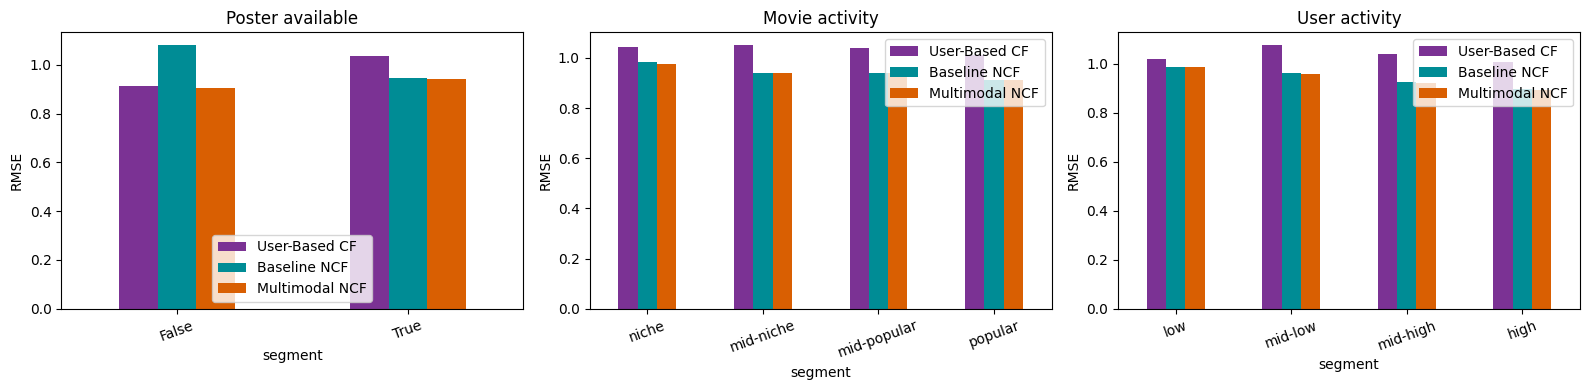


=== Poster available ===
segment     n  user_cf_RMSE  baseline_RMSE  multimodal_RMSE  user_cf_MAE  baseline_MAE  multimodal_MAE  baseline_vs_cf_RMSE_gain_%  multimodal_vs_baseline_RMSE_gain_%  baseline_vs_cf_MAE_gain_%  multimodal_vs_baseline_MAE_gain_%
  False    47        0.9142         1.0799           0.9061       0.7254        0.9509          0.7521                    -18.1186                             16.0905                   -31.0843                            20.9051
   True 49953        1.0375         0.9445           0.9414       0.8022        0.7326          0.7296                      8.9652                              0.3238                     8.6807                             0.4097

=== Movie activity ===
    segment     n  user_cf_RMSE  baseline_RMSE  multimodal_RMSE  user_cf_MAE  baseline_MAE  multimodal_MAE  baseline_vs_cf_RMSE_gain_%  multimodal_vs_baseline_RMSE_gain_%  baseline_vs_cf_MAE_gain_%  multimodal_vs_baseline_MAE_gain_%
      niche 12500        1.045

In [55]:
def rmse_np(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def summarize_segment(frame, segment_col):
    rows = []
    for segment_value, group in frame.groupby(segment_col, observed=True):
        if len(group) < 30:
            continue
        rows.append({
            'segment': str(segment_value),
            'n': len(group),
            'user_cf_RMSE': rmse_np(group['actual'], group['user_cf_pred']),
            'baseline_RMSE': rmse_np(group['actual'], group['baseline_pred']),
            'multimodal_RMSE': rmse_np(group['actual'], group['multimodal_pred']),
            'user_cf_MAE': float(group['user_cf_abs_error'].mean()),
            'baseline_MAE': float(group['baseline_abs_error'].mean()),
            'multimodal_MAE': float(group['multimodal_abs_error'].mean()),
        })
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out['baseline_vs_cf_RMSE_gain_%'] = (out['user_cf_RMSE'] - out['baseline_RMSE']) / out['user_cf_RMSE'] * 100
    out['multimodal_vs_baseline_RMSE_gain_%'] = (out['baseline_RMSE'] - out['multimodal_RMSE']) / out['baseline_RMSE'] * 100
    out['baseline_vs_cf_MAE_gain_%'] = (out['user_cf_MAE'] - out['baseline_MAE']) / out['user_cf_MAE'] * 100
    out['multimodal_vs_baseline_MAE_gain_%'] = (out['baseline_MAE'] - out['multimodal_MAE']) / out['baseline_MAE'] * 100
    return out

segments = {
    'Poster available': 'poster_available',
    'Movie activity': 'movie_activity_bin',
    'User activity': 'user_activity_bin',
}

fig, axes = plt.subplots(1, len(segments), figsize=(16, 4), sharey=False)
segment_tables = {}
for ax, (title, column) in zip(axes, segments.items()):
    table = summarize_segment(eval_df, column)
    segment_tables[title] = table
    if table.empty:
        ax.set_title(title)
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center')
        continue
    plot_df = table.set_index('segment')[['user_cf_RMSE', 'baseline_RMSE', 'multimodal_RMSE']]
    plot_df.rename(columns={
        'user_cf_RMSE': 'User-Based CF',
        'baseline_RMSE': 'Baseline NCF',
        'multimodal_RMSE': 'Multimodal NCF',
    }).plot(kind='bar', ax=ax, color=['#7b3294', '#008c95', '#d95f02'])
    ax.set_title(title)
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

for title, table in segment_tables.items():
    print(f'\n=== {title} ===')
    if table.empty:
        print('Not enough data')
    else:
        print(table.to_string(index=False, float_format='{:.4f}'.format))


Base multimodal subset RMSE=0.9410, MAE=0.7291
          feature_group  RMSE_when_permuted  MAE_when_permuted  RMSE_increase  MAE_increase
        meta_vote_count             0.94203            0.73002        0.00104       0.00087
      meta_vote_average             0.94202            0.73081        0.00102       0.00166
poster_visual_embedding             0.94182            0.72997        0.00082       0.00082
        meta_popularity             0.94180            0.72992        0.00080       0.00077
                  Drama             0.94118            0.72928        0.00019       0.00013
            Documentary             0.94117            0.72930        0.00017       0.00015
              Adventure             0.94114            0.72933        0.00015       0.00018
                 Action             0.94112            0.72926        0.00012       0.00011
                 Family             0.94111            0.72930        0.00012       0.00015
                 Horror          

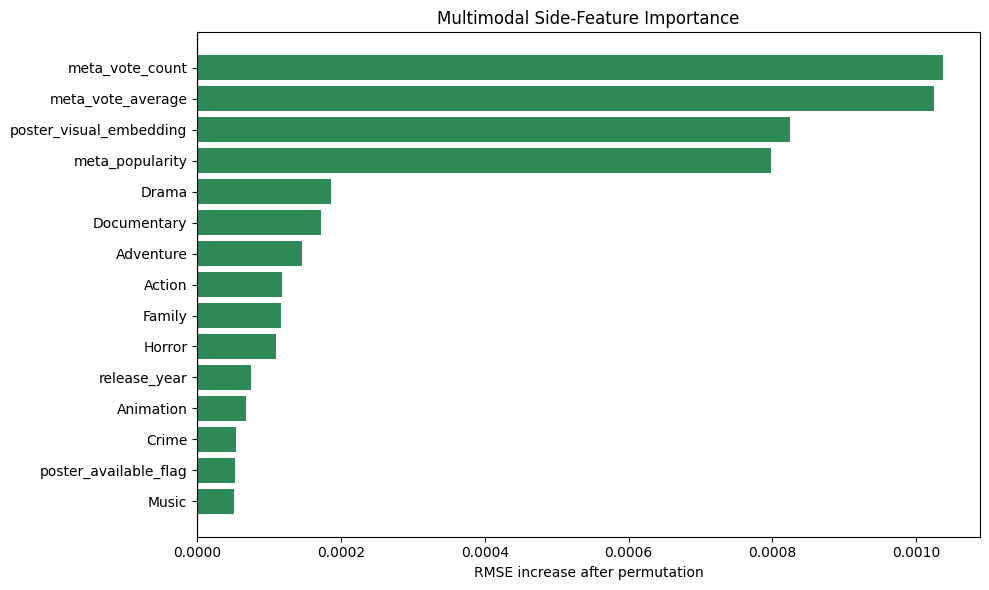

In [56]:
def permutation_importance_multimodal(model, base_inputs, y_true, max_rows=10000, seed=SEED):
    rng = np.random.default_rng(seed)
    n = min(max_rows, len(y_true))
    sample_idx = rng.choice(len(y_true), size=n, replace=False)
    y_sample = y_true[sample_idx]
    sampled_inputs = {name: values[sample_idx].copy() for name, values in base_inputs.items()}

    base_pred = predict_ratings(model, sampled_inputs)
    base_rmse = rmse_np(y_sample, base_pred)
    base_mae = float(mean_absolute_error(y_sample, base_pred))

    groups = [(name, 'metadata', cols) for name, cols in metadata_feature_groups]
    poster_visual = sampled_inputs['poster_emb'][:, :-1]
    poster_flag = sampled_inputs['poster_emb'][:, -1]
    if poster_visual.shape[1] > 0 and np.any(poster_visual != 0):
        groups.append(('poster_visual_embedding', 'poster_visual', None))
    if np.unique(poster_flag).size > 1:
        groups.append(('poster_available_flag', 'poster_flag', None))

    rows = []
    for name, source, cols in groups:
        perturbed = {key: value.copy() for key, value in sampled_inputs.items()}
        if source == 'metadata':
            for col in cols:
                perturbed['metadata'][:, col] = rng.permutation(perturbed['metadata'][:, col])
        elif source == 'poster_visual':
            perm = rng.permutation(n)
            perturbed['poster_emb'][:, :-1] = perturbed['poster_emb'][perm, :-1]
        elif source == 'poster_flag':
            perturbed['poster_emb'][:, -1] = rng.permutation(perturbed['poster_emb'][:, -1])

        pred = predict_ratings(model, perturbed)
        rmse = rmse_np(y_sample, pred)
        mae = float(mean_absolute_error(y_sample, pred))
        rows.append({
            'feature_group': name,
            'RMSE_when_permuted': rmse,
            'MAE_when_permuted': mae,
            'RMSE_increase': rmse - base_rmse,
            'MAE_increase': mae - base_mae,
        })

    return pd.DataFrame(rows).sort_values('RMSE_increase', ascending=False).reset_index(drop=True), base_rmse, base_mae

feature_importance_df, base_perm_rmse, base_perm_mae = permutation_importance_multimodal(
    multi_model,
    multi_test_inputs,
    r_test,
)

print(f'Base multimodal subset RMSE={base_perm_rmse:.4f}, MAE={base_perm_mae:.4f}')
print(feature_importance_df.head(15).to_string(index=False, float_format='{:.5f}'.format))

top_importance = feature_importance_df.head(15).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top_importance['feature_group'], top_importance['RMSE_increase'], color='seagreen')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Multimodal Side-Feature Importance')
plt.xlabel('RMSE increase after permutation')
plt.tight_layout()
plt.show()


## Recommendations

This demo recommends movies for an active training user. It only ranks movies whose embeddings were actually trained, which avoids sample-mode recommendations from random untrained movie vectors.


Recommendation candidate movies: 7,699
Top-10 recommendations for user_idx=72314

--- User-Based CF ---
 rank  movie_idx                         title                                                    genres   poster_source  rating_count  predicted_rating
    1       2114                      Saboteur                                      Thriller|War|Mystery        tmdb_all            15               5.0
    2       7085         My Darling Clementine                   Drama|Western|Romance|History|Biography        tmdb_all             8               5.0
    3      51844                          Mute                          Science Fiction|Mystery|Thriller        tmdb_all             5               5.0
    4       3841            Digimon: The Movie Fantasy|Animation|Science Fiction|Family|Action|Adventure        tmdb_all             9               5.0
    5       2562                  The Wolf Man                                      Horror|Drama|Fantasy        tmdb_all           

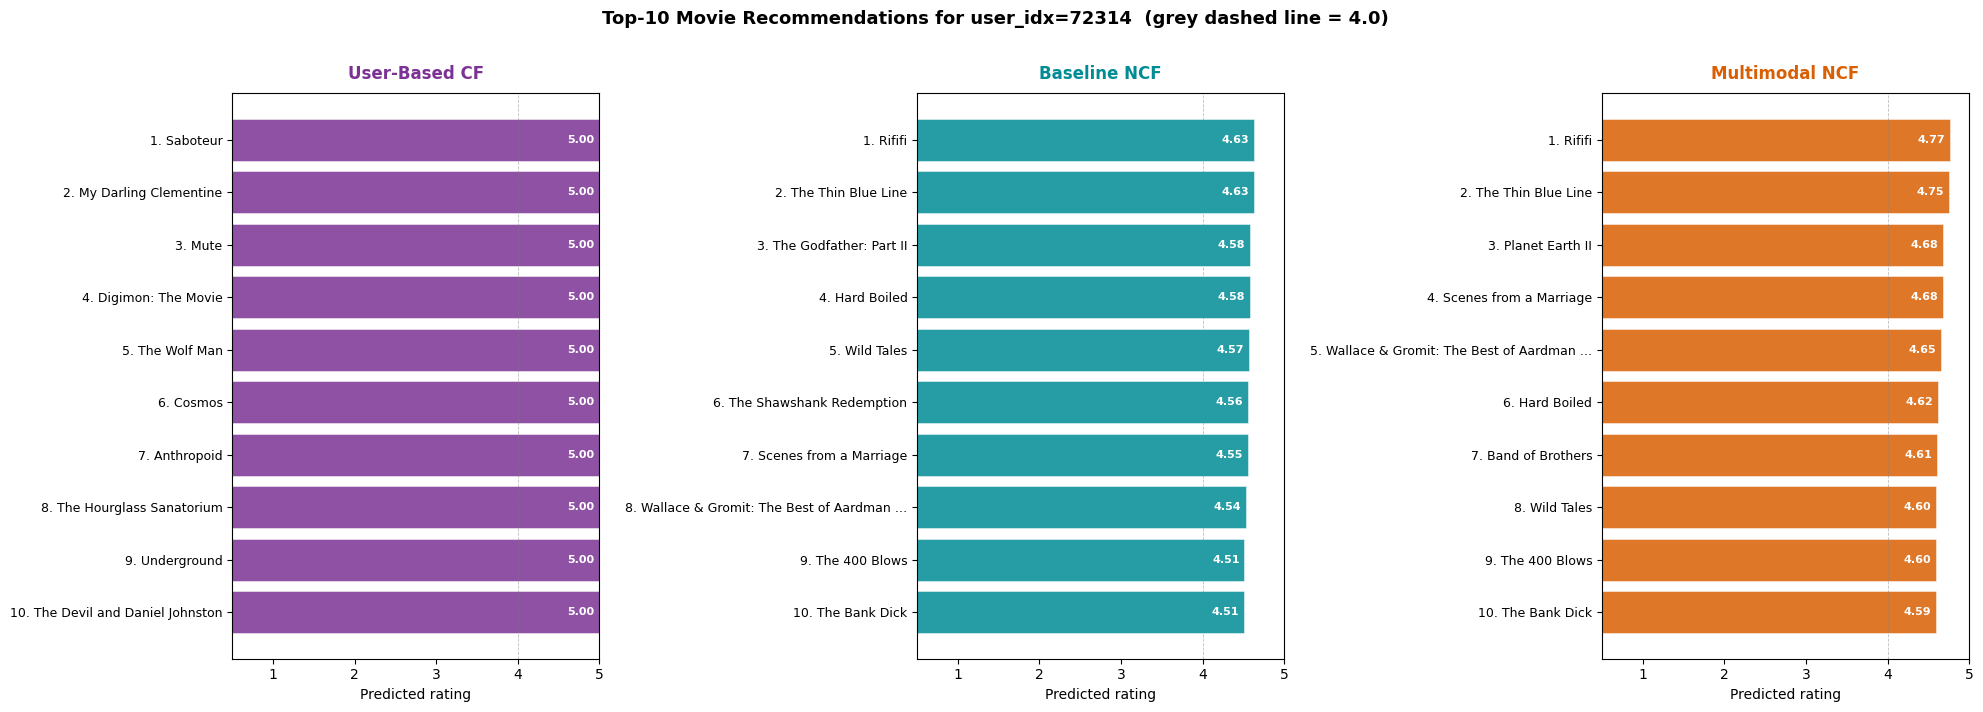

In [60]:
def build_recommendation_catalog(movie_catalog, df_train, min_movie_ratings=5):
    rating_counts = df_train.groupby('movie_idx').size().rename('rating_count')
    catalog = movie_catalog.drop_duplicates('movie_idx').set_index('movie_idx').copy()
    catalog = catalog.join(rating_counts, how='inner')
    trained_movie_idxs = np.unique(m_train)
    catalog = catalog.loc[catalog.index.intersection(trained_movie_idxs)]

    filtered = catalog[catalog['rating_count'] >= min_movie_ratings]
    if filtered.empty:
        print(f'No movies met min_movie_ratings={min_movie_ratings}; falling back to all trained candidate movies.')
        filtered = catalog
    if filtered.empty:
        raise ValueError('No trained movie candidates are available for recommendation.')
    return filtered.sort_values('rating_count', ascending=False)


def choose_demo_user(min_train_ratings=10):
    train_user_counts = pd.Series(u_train).value_counts()
    eligible = train_user_counts[train_user_counts >= min_train_ratings]
    if eligible.empty:
        return int(train_user_counts.index[0])
    return int(eligible.index[0])


def recommend_top_n(model, user_id, df_all, poster_emb_arr, meta_lookup_arr,
                    movie_catalog_df, n=10, use_multimodal=False, use_user_cf=False):
    seen_movies = set(df_all[df_all['user_idx'] == user_id]['movie_idx'].values)
    candidate_movies = movie_catalog_df.index.to_numpy(dtype=np.int32)
    if seen_movies:
        candidate_movies = candidate_movies[~np.isin(candidate_movies, list(seen_movies))]
    if len(candidate_movies) == 0:
        raise ValueError(f'No recommendation candidates left for user_idx={user_id}.')

    users_arr = np.full(len(candidate_movies), user_id, dtype=np.int32)
    movies_arr = candidate_movies.astype(np.int32)

    if use_user_cf:
        preds = model.predict(users_arr, movies_arr)
    elif use_multimodal:
        inputs = {
            'user_idx'  : users_arr,
            'movie_idx' : movies_arr,
            'metadata'  : meta_lookup_arr[movies_arr],
            'poster_emb': poster_emb_arr[movies_arr]
        }
        preds = predict_ratings(model, inputs, batch_size=2048)
    else:
        inputs = {'user_idx': users_arr, 'movie_idx': movies_arr}
        preds = predict_ratings(model, inputs, batch_size=2048)
    top_n_idx = np.argsort(preds)[::-1][:n]
    top_movies = movies_arr[top_n_idx]
    top_scores = preds[top_n_idx]

    recs = []
    for rank, (m_idx, score) in enumerate(zip(top_movies, top_scores), start=1):
        row = movie_catalog_df.loc[m_idx]
        recs.append({
            'rank': rank,
            'movie_idx': int(m_idx),
            'title': row.get('final_title', f'movie_{m_idx}'),
            'genres': row.get('final_genres_str', ''),
            'poster_source': row.get('poster_url_source', ''),
            'rating_count': int(row.get('rating_count', 0)),
            'predicted_rating': round(float(score), 3),
        })
    return pd.DataFrame(recs)


recommendation_catalog = build_recommendation_catalog(movie_catalog, df, min_movie_ratings=5)
DEMO_USER = choose_demo_user(min_train_ratings=10)
print(f'Recommendation candidate movies: {len(recommendation_catalog):,}')
print(f'Top-10 recommendations for user_idx={DEMO_USER}')

user_cf_recs = recommend_top_n(
    user_cf_model, DEMO_USER, df, poster_embeddings, meta_lookup,
    recommendation_catalog, n=10, use_user_cf=True
)
baseline_recs = recommend_top_n(
    baseline_model, DEMO_USER, df, poster_embeddings, meta_lookup,
    recommendation_catalog, n=10, use_multimodal=False
)
multimodal_recs = recommend_top_n(
    multi_model, DEMO_USER, df, poster_embeddings, meta_lookup,
    recommendation_catalog, n=10, use_multimodal=True
)

print('\n--- User-Based CF ---')
print(user_cf_recs.to_string(index=False))

print('\n--- Baseline Model ---')
print(baseline_recs.to_string(index=False))

print('\n--- Multimodal Model ---')
print(multimodal_recs.to_string(index=False))

rec_sets = {
    'User-Based CF': set(user_cf_recs['movie_idx']),
    'Baseline NCF': set(baseline_recs['movie_idx']),
    'Multimodal NCF': set(multimodal_recs['movie_idx']),
}
for left_name, right_name in [('User-Based CF', 'Baseline NCF'), ('Baseline NCF', 'Multimodal NCF'), ('User-Based CF', 'Multimodal NCF')]:
    overlap = sorted(rec_sets[left_name].intersection(rec_sets[right_name]))
    print(f'\nTop-10 overlap ({left_name} vs {right_name}): {len(overlap)} movies -> {overlap}')

combined_recs = user_cf_recs[['movie_idx', 'title', 'rank', 'predicted_rating']].rename(
    columns={'rank': 'user_cf_rank', 'predicted_rating': 'user_cf_score'}
).merge(
    baseline_recs[['movie_idx', 'rank', 'predicted_rating']].rename(
        columns={'rank': 'baseline_rank', 'predicted_rating': 'baseline_score'}
    ),
    on='movie_idx',
    how='outer'
).merge(
    multimodal_recs[['movie_idx', 'rank', 'predicted_rating']].rename(
        columns={'rank': 'multimodal_rank', 'predicted_rating': 'multimodal_score'}
    ),
    on='movie_idx',
    how='outer'
)
combined_recs['title'] = combined_recs['title'].fillna(
    combined_recs['movie_idx'].map(recommendation_catalog['final_title'])
)
combined_recs['baseline_minus_cf'] = combined_recs['baseline_score'] - combined_recs['user_cf_score']
combined_recs['multimodal_minus_baseline'] = combined_recs['multimodal_score'] - combined_recs['baseline_score']
print('\n=== Recommendation Difference Table ===')
print(combined_recs.sort_values(['multimodal_rank', 'baseline_rank', 'user_cf_rank'], na_position='last').to_string(index=False))

model_rec_data = [
    ('User-Based CF',  user_cf_recs,   '#7b3294'),
    ('Baseline NCF',   baseline_recs,  '#008c95'),
    ('Multimodal NCF', multimodal_recs,'#d95f02'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=False)

def short_title(t, max_len=38):
    t = str(t)
    return t[:max_len] + '…' if len(t) > max_len else t

for ax, (model_name, recs, color) in zip(axes, model_rec_data):
    labels = [f"{row['rank']}. {short_title(row['title'])}" for _, row in recs.iterrows()]
    scores = recs['predicted_rating'].values
    y_pos  = np.arange(len(labels))

    bars = ax.barh(y_pos, scores, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(RATING_MIN, RATING_MAX)
    ax.set_xlabel('Predicted rating', fontsize=10)
    ax.set_title(model_name, fontsize=12, fontweight='bold', color=color, pad=10)
    ax.invert_yaxis()
    ax.axvline(4.0, color='grey', linewidth=0.6, linestyle='--', alpha=0.5)

    for bar, score in zip(bars, scores):
        ax.text(
            min(bar.get_width() - 0.06, RATING_MAX - 0.06),
            bar.get_y() + bar.get_height() / 2,
            f'{score:.2f}',
            va='center', ha='right', fontsize=8, color='white', fontweight='bold'
        )

fig.suptitle(
    f'Top-10 Movie Recommendations for user_idx={DEMO_USER}  '
    f'(grey dashed line = 4.0)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


## Save Models

The final trained models are saved under the project-level `saved_models/` folder so they are separate from the generated dataset files.


In [58]:
save_dir = PROJECT_ROOT / 'saved_models'
save_dir.mkdir(parents=True, exist_ok=True)

baseline_model.save(save_dir / 'baseline_ncf.keras')
multi_model.save(save_dir / 'multimodal_ncf.keras')

print('Models saved to:', save_dir)
print('  baseline_ncf.keras')
print('  multimodal_ncf.keras')


Models saved to: C:\Users\murad\Desktop\master\Neural networks\GroupProject\final\saved_models
  baseline_ncf.keras
  multimodal_ncf.keras


## Full Dataset Note

`USE_SAMPLE = True` is best for fast experiments and presentations. The traditional user-based CF baseline is designed for this sample-mode comparison; set `USE_SAMPLE = False` only when the machine has enough memory/time for the full MovieLens ratings file and larger CF evaluation.
